In [235]:
import geohexgrid as ghg
import numpy as np
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint, GeometryCollection
import geopandas as gpd
import pandas as pd
from math import comb
import numpy as np
import matplotlib.pyplot as plt

## Get the shape of some city

  id                                     geometry
0  1  POLYGON ((0 0, 0 100, 100 100, 100 0, 0 0))


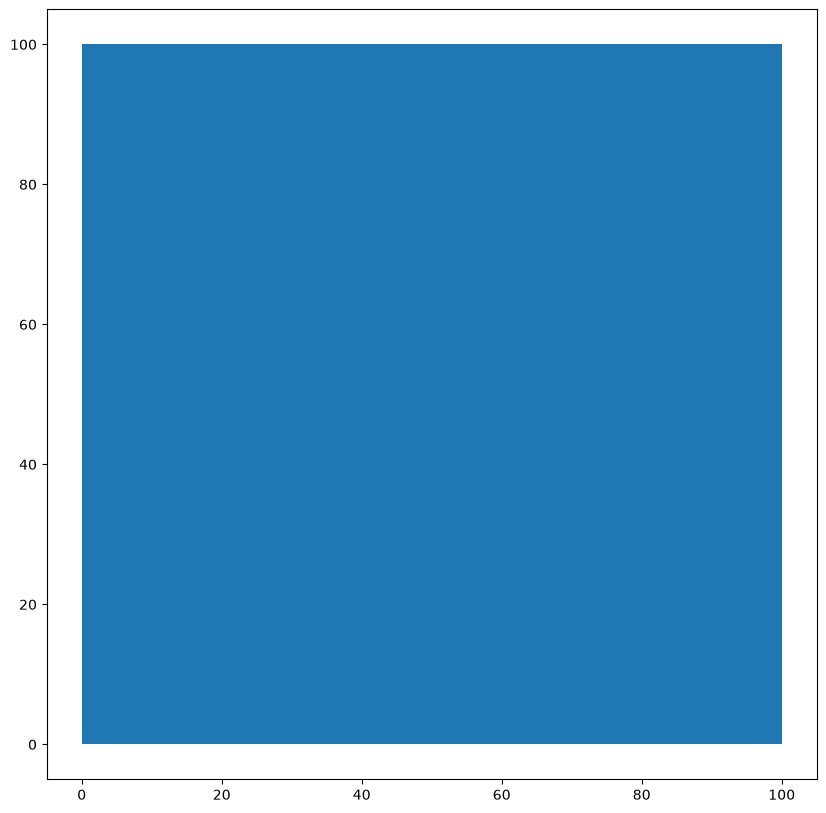

In [236]:
d = {'id': ['1'], 'geometry': [Polygon([(0., 0.), (0., 100.), (100., 100.), (100., 0.)])]}
base = gpd.GeoDataFrame(data=d, crs=None)
background = base.plot(figsize=(10, 10))
print(base)

## Create hex grid

<Axes: >

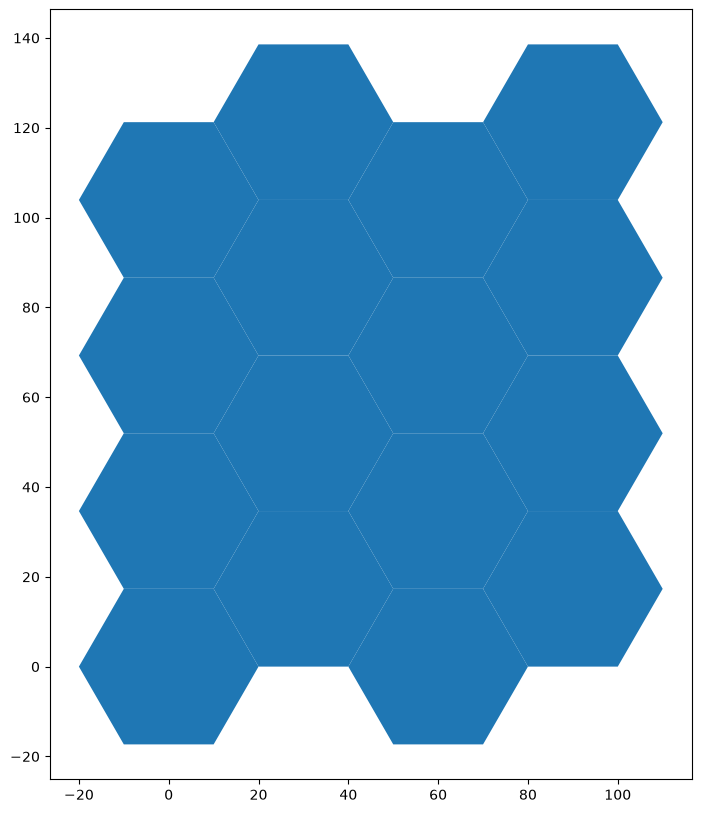

In [237]:
grid = ghg.make_grid_from_bounds(0., 0., 100., 100., R=20.)
grid.plot(figsize=(10, 10))

In [238]:
type(grid)

geopandas.geodataframe.GeoDataFrame

In [239]:
hex_example = grid.iat[0,-1]
hex_example
print(hex_example)

POLYGON ((-10 -17.32050807568877, 10 -17.32050807568877, 20 0, 10 17.32050807568877, -10 17.32050807568877, -20 0, -10 -17.32050807568877))


In [240]:
print(f"area: {hex_example.area}")
print(f"boundary: {hex_example.boundary}")
print(f"bounds: {hex_example.bounds}")
print(f"centroid: {hex_example.centroid}")

area: 1039.2304845413262
boundary: LINESTRING (-10 -17.32050807568877, 10 -17.32050807568877, 20 0, 10 17.32050807568877, -10 17.32050807568877, -20 0, -10 -17.32050807568877)
bounds: (-20.0, -17.32050807568877, 20.0, 17.32050807568877)
centroid: POINT (2.917205616084103e-16 0)


## Extract seed points

In [241]:
grid['centroid'] = grid['geometry'].centroid
grid.head()

,cell_id,geometry,centroid
0,"0,0","POLYGON ((-10 -17.32051, 10 -17.32051, 20 0, 1...",POINT (2.91721e-16 0)
1,"1,1","POLYGON ((20 0, 40 0, 50 17.32051, 40 34.64102...",POINT (30 17.32051)
2,"2,0","POLYGON ((50 -17.32051, 70 -17.32051, 80 0, 70...",POINT (60 0)
3,"3,1","POLYGON ((80 0, 100 0, 110 17.32051, 100 34.64...",POINT (90 17.32051)
4,"0,2","POLYGON ((-10 17.32051, 10 17.32051, 20 34.641...",POINT (2.91721e-16 34.64102)


<Axes: >

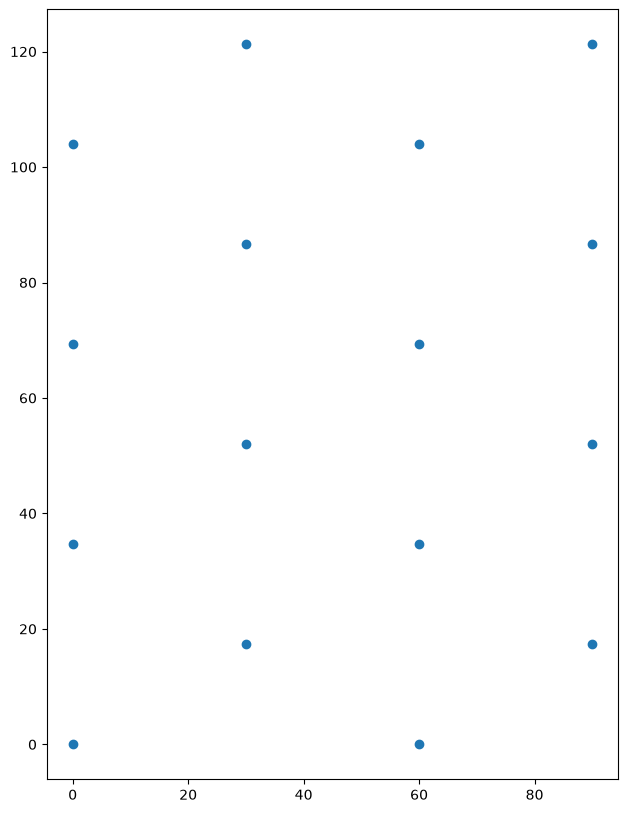

In [242]:
centroids = grid["centroid"]
centroids.plot(figsize=(10, 10))

## Create demand matrix

### Compute seed point pairs

no. of seed points: 16
no. of pairs is actually: 120
no. of pairs should be: 120


<Axes: >

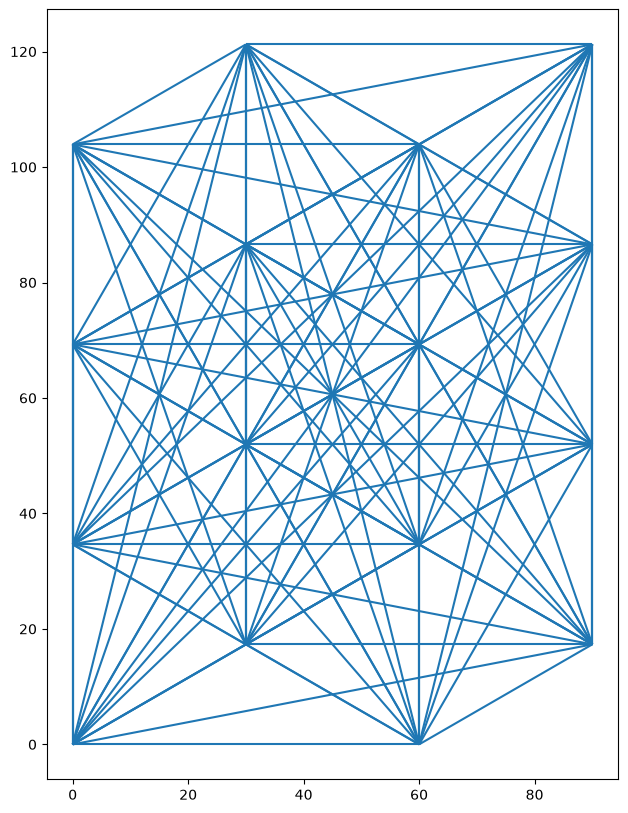

In [243]:
def od_pairs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    seed_points = gdf['cell_id'].values.tolist()
    geo = gdf['centroid'].values.tolist()
    n = len(seed_points)
    ids = []
    origins = []
    dests = []
    lines = []
    for i in range(n):
        for j in range(i+1, n):
            # print(f'seed_points[i]: {seed_points[i]}, seed_points[j]: {seed_points[j]}')
            # print(f'geo[i]: {geo[i]}, geo[j]: {geo[j]}')
            ids.append((seed_points[i], seed_points[j]))
            origins.append(seed_points[i])
            dests.append(seed_points[j])
            lines.append(LineString([geo[i], geo[j]]))
    return gpd.GeoDataFrame({'pair': ids, 'u': origins, 'v': dests, 'geometry': lines})

test_pairs = od_pairs(grid)
print(f'no. of seed points: {grid.shape[0]}')
print(f'no. of pairs is actually: {test_pairs.shape[0]}')
print(f'no. of pairs should be: {comb(grid.shape[0], 2)}')
test_pairs.head()
test_pairs.plot(figsize=(10, 10))

### Generate random demand

In [244]:
def generate_demand(mean: float, std: float, n: int) -> np.ndarray:
    seed: int = 8920299146682435938
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    return rng.normal(mean, std, size=n)

# Code from NumPy docs
def plot_demand_distribution(mean: float, std: float, demand: np.ndarray):
    count, bins, _ = plt.hist(demand, 30, density=True)
    plt.plot(bins, 1/(std * np.sqrt(2 * np.pi)) *
                   np.exp( - (bins - mean)**2 / (2 * std**2) ),
             linewidth=2, color='r')
    plt.show()

In [245]:
P = test_pairs.shape[0] # number of seed point pairs
mean: float = 0.5
std: float = 0.1
test_demand = generate_demand(mean, std, P)
print(type(test_demand))
print(len(test_demand))
print(len(test_demand))
test_demand

<class 'numpy.ndarray'>
120
120


array([0.41622419, 0.42797627, 0.46871791, 0.55599697, 0.47781444,
       0.49492817, 0.67687184, 0.63156416, 0.50617042, 0.44096554,
       0.57618405, 0.53216953, 0.62667603, 0.28256578, 0.66066127,
       0.6505923 , 0.50232399, 0.47034064, 0.53751612, 0.56674942,
       0.48457331, 0.34217347, 0.49590754, 0.55585018, 0.33303848,
       0.65758461, 0.55888272, 0.68096704, 0.37446437, 0.45671717,
       0.45460938, 0.59742719, 0.64743839, 0.37786992, 0.46217563,
       0.58662992, 0.41614735, 0.47553357, 0.40674193, 0.45884501,
       0.58221351, 0.49895318, 0.51059277, 0.60424525, 0.53680577,
       0.3334265 , 0.54253038, 0.44440123, 0.45183355, 0.37179606,
       0.55136544, 0.50212957, 0.6244822 , 0.334202  , 0.55901543,
       0.65911842, 0.47173019, 0.47253105, 0.46878892, 0.36363287,
       0.28206637, 0.46075061, 0.54088286, 0.44939726, 0.53709533,
       0.52153747, 0.45623075, 0.46149314, 0.50452572, 0.39285051,
       0.55525428, 0.35015395, 0.27280277, 0.5080756 , 0.48435

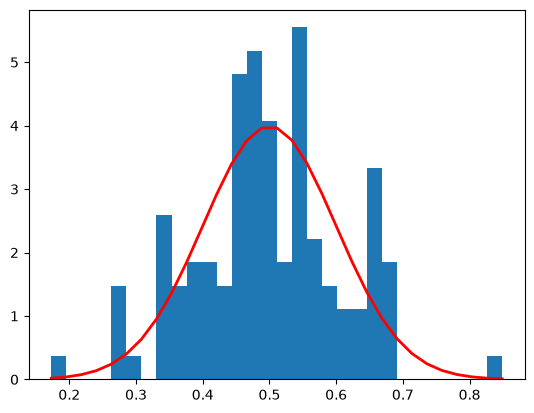

In [246]:
plot_demand_distribution(mean, std, test_demand)

In [247]:
test_pairs.head()

,pair,u,v,geometry
0,"(0,0, 1,1)","0,0","1,1","LINESTRING (2.91721e-16 0, 30 17.32051)"
1,"(0,0, 2,0)","0,0","2,0","LINESTRING (2.91721e-16 0, 60 0)"
2,"(0,0, 3,1)","0,0","3,1","LINESTRING (2.91721e-16 0, 90 17.32051)"
3,"(0,0, 0,2)","0,0","0,2","LINESTRING (2.91721e-16 0, 2.91721e-16 34.64102)"
4,"(0,0, 1,3)","0,0","1,3","LINESTRING (2.91721e-16 0, 30 51.96152)"


In [248]:
demand_matrix = pd.concat([test_pairs, pd.Series(test_demand)], axis=1)
demand_matrix.columns = ['pair', 'u', 'v', 'geometry', 'demand']
demand_matrix.head()
demand_matrix.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pair      120 non-null    object  
 1   u         120 non-null    str     
 2   v         120 non-null    str     
 3   geometry  120 non-null    geometry
 4   demand    120 non-null    float64 
dtypes: float64(1), geometry(1), object(1), str(2)
memory usage: 5.5+ KB


In [249]:
ordered_demand = demand_matrix.sort_values(by=['demand', 'pair'], ascending=False)
ordered_demand.head()

,pair,u,v,geometry,demand
99,"(1,5, 2,4)","1,5","2,4","LINESTRING (30 86.603, 60 69.282)",0.848836
27,"(1,1, 2,6)","1,1","2,6","LINESTRING (30 17.321, 60 103.923)",0.680967
6,"(0,0, 3,3)","0,0","3,3","LINESTRING (2.917e-16 0, 90 51.962)",0.676872
80,"(2,2, 0,6)","2,2","0,6","LINESTRING (60 34.641, -2.917e-16 103.923)",0.670358
81,"(2,2, 1,7)","2,2","1,7","LINESTRING (60 34.641, 30 121.244)",0.670202


## Calculate total demand

In [250]:
total_demand = float(demand_matrix['demand'].sum())
total_demand

59.612464278760754

In [251]:
seed_points = grid
seed_points.columns = ['id', 'geometry', 'centroid']
seed_points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        16 non-null     str     
 1   geometry  16 non-null     geometry
 2   centroid  16 non-null     geometry
dtypes: geometry(2), str(1)
memory usage: 564.0 bytes


In [252]:
seed_points["total_demand"] = seed_points.apply(
    lambda x:
        sum(demand_matrix[(demand_matrix.u == x.id) | (demand_matrix.v == x.id)].demand),
    axis = 1
)
seed_points.sort_values('total_demand', ascending=False).head()

,id,geometry,centroid,total_demand
6,"2,2","POLYGON ((50 17.321, 70 17.321, 80 34.641, 70 ...",POINT (60 34.641),8.412470
12,"0,6","POLYGON ((-10 86.603, 10 86.603, 20 103.923, 1...",POINT (-2.917e-16 103.923),7.804757
0,"0,0","POLYGON ((-10 -17.321, 10 -17.321, 20 0, 10 17...",POINT (2.917e-16 0),7.775487
14,"2,6","POLYGON ((50 86.603, 70 86.603, 80 103.923, 70...",POINT (60 103.923),7.762737
9,"1,5","POLYGON ((20 69.282, 40 69.282, 50 86.603, 40 ...",POINT (30 86.603),7.746136


Text(0.5, 1.0, 'Total demand per hexagon')

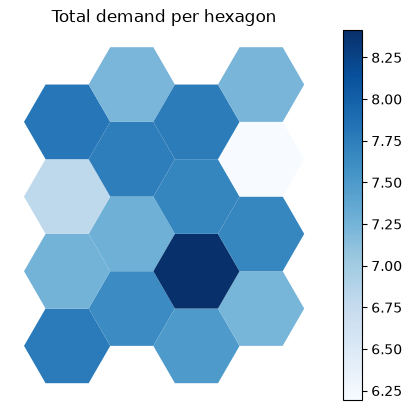

In [253]:

fig, ax = plt.subplots(1,1)
seed_points.plot(
    ax=ax,
    column="total_demand",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Total demand per hexagon")